# **Proyecto Tech - Inteligencia Artificial**

Caren Juliana Jaimes Leal

Proyecto: probabilidad de diabetes en sangre.

Descripción del proyecto:
Este proyecto tiene como objetivo hacer uso de un Feed Forward Neuronal Network (FFNN) más específicamente un Árbol de Decisión, para realizar la clasificación del nivel de diabetes en una persona al tomar variables sobre su condición de salud y datos físicos. Entrenando el modelo con Diabetes Dataset obtenida en Kaggle. Este proyecto requiere entregar 3 datos de clasificación Sin diabetes, Diabetes tipo 1, Diabetes tipo 2 u Otro.

Objetivos:

*   Construir el modelo de Árbol de Decisión.
*   Entrenar el modelo con los datos obtenidos en Diabetes Dataset.
*   Evaluar el modelo con el conjunto de datos de prueba.
*   Probar el modelo con datos ingresados de una persona x.

Para este proyecto se inicia con el llamado de las librerias. Se hace uso de pandas, NumPy y MatplotLib para el codigo y creación de las graficas. Tensor flow para el entrenamiento del modelo.

In [ ]:
####### Módulos de análisis de datos
import pandas as pd
import numpy as np

###### Bibliotecas de visualización
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

####### Bibliotecas de Machine Learning
! pip install mglearn
from sklearn.datasets import *
import numpy as np
import matplotlib.pyplot as plt
import mglearn

###### Bibliotecas para las redes neuronales
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
!pip install opendatasets
import opendatasets as od

In [ ]:
dataset_link = "https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset?select=diabetes.csv"
od.download(dataset_link)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: julianajaimes
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset


100%|██████████| 8.91k/8.91k [00:00<00:00, 12.9MB/s]

In [ ]:
from os import listdir
import os
listdir()

['.config', 'cache', 'diabetes-dataset', 'sample_data']

In [ ]:
os.chdir("/content/diabetes-dataset")
os.listdir()

['diabetes.csv']

# **Limpieza**
Seleccionamos la data cargada y la guardamos en variables que nos diferencien los datos de entrenamiento con los datos de testeo. Yo cargue la misma data dos veces para hacer comparaciones.

In [ ]:
#Leer que datos hay en mi colomna que sean relevantes para la prediccion
df_test = pd.read_csv('/content/diabetes-dataset/diabetes.csv')
df_train = pd.read_csv('/content/diabetes-dataset/diabetes.csv')
df_test.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [ ]:
df_train.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


Podemos observar que nuestra tabla de datos nos entrega las siguientes columnas: cantidad de Embarazos, Glucosa en sangre, Presión arterial, Grosor de la piel, Insulina, IMC, Función del pedigrí de la diabetes (hereditario), Edad y Resultado

In [ ]:
###### Evaluamos el tamaño de los datos de entrenamiento y prueba
print(df_train.shape)
print(df_test.shape)

(768, 9)
(768, 9)


In [ ]:
df_train.dtypes, df_test.dtypes

(Pregnancies                   int64
 Glucose                       int64
 BloodPressure                 int64
 SkinThickness                 int64
 Insulin                       int64
 BMI                         float64
 DiabetesPedigreeFunction    float64
 Age                           int64
 Outcome                       int64
 dtype: object,
 Pregnancies                   int64
 Glucose                       int64
 BloodPressure                 int64
 SkinThickness                 int64
 Insulin                       int64
 BMI                         float64
 DiabetesPedigreeFunction    float64
 Age                           int64
 Outcome                       int64
 dtype: object)

In [ ]:
df_test.isnull() #Detecta valores faltantes para un objeto similar a una matriz
df_train.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


<Axes: >

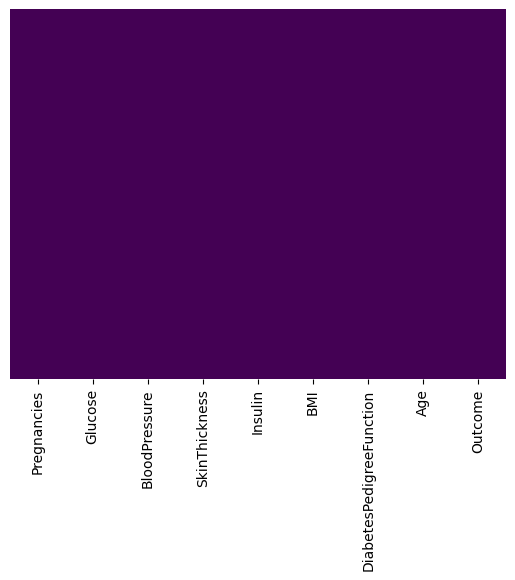

In [ ]:
######## Mapa de calor de valores faltantes
sns.heatmap(df_train.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

*Conclusion de la limpieza de datos:*
Este ejercicio no tenia datos vacios, las variables contenidas en el DataSet son necesarias para hacer la predicción de los datos.

# Clasificación
Se hacen las clasificaciones por edades
Se hace clasificacion segun su riezgo de diabetes, alto, medio, bajo.

In [ ]:
## Contenedores para el riesgo
def diabetes_level(level):
    b = ''
    if level <= 0.1:
        b = 'Ninguno'
    elif level <= 0.5:
        b = 'Bajo'
    elif level <= 0.9:
        b = 'Medio'
    else:
        b = 'Alto'
    return b

In [ ]:
df_train['Outcome'] = df_train['Outcome'].astype(float)
df_test['Outcome'] = df_test['Outcome'].astype(float)

In [ ]:
#Se aplica la clasificacion a la data detest y de train, esto crea una columna adicional en la que se guarda la clasificación por edades
df_test['diabetes_level'] = df_train['Outcome'].map(diabetes_level)
df_train['diabetes_level'] = df_test['Outcome'].map(diabetes_level)
df_test.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,diabetes_level,...,age_group_Joven_adulto,age_group_Viejo,age_group_adulto,age_group_mediana_edad,age_group_Anciano,age_group_Joven_adulto,age_group_Viejo,age_group_adulto,age_group_mediana_edad,age_group
0,6,148,72,35,0,33.6,0.627,50,1.0,Alto,...,0,0,0,1,0,0,0,0,1,mediana_edad
1,1,85,66,29,0,26.6,0.351,31,0.0,Ninguno,...,1,0,0,0,0,1,0,0,0,Joven_adulto
2,8,183,64,0,0,23.3,0.672,32,1.0,Alto,...,1,0,0,0,0,1,0,0,0,Joven_adulto
3,1,89,66,23,94,28.1,0.167,21,0.0,Ninguno,...,1,0,0,0,0,1,0,0,0,Joven_adulto
4,0,137,40,35,168,43.1,2.288,33,1.0,Alto,...,1,0,0,0,0,1,0,0,0,Joven_adulto


In [ ]:
df_train.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,float64
diabetes_level,object


In [ ]:
#Se aplican dummis para discriminar en cada columna agrupando los valores en 0 o 1
df_train = pd.get_dummies(df_train,columns=['age_group'], dtype=int)
df_test = pd.get_dummies(df_test,columns=['age_group'], dtype=int)
df_test.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,diabetes_level,age_group_Anciano,age_group_Joven_adulto,age_group_Viejo,age_group_adulto,age_group_mediana_edad,age_group_Anciano,age_group_Joven_adulto,age_group_Viejo,age_group_adulto,age_group_mediana_edad
0,6,148,72,35,0,33.6,0.627,50,1,high,0,0,0,0,1,0,0,0,0,1
1,1,85,66,29,0,26.6,0.351,31,0,null,0,1,0,0,0,0,1,0,0,0
2,8,183,64,0,0,23.3,0.672,32,1,high,0,1,0,0,0,0,1,0,0,0
3,1,89,66,23,94,28.1,0.167,21,0,null,0,1,0,0,0,0,1,0,0,0
4,0,137,40,35,168,43.1,2.288,33,1,high,0,1,0,0,0,0,1,0,0,0


# Corte del Data Set
Como vamos a hacer la predicción de los resultados si es posible que tenga o no tenga diabetes segun las variables, eliminamos del entrenamiento la columna de resultados (Outcome)

In [ ]:
#Me traigo la libreria para cortar la data
from sklearn.model_selection import train_test_split

#Defino mis caracteristicas para el entrenamiento, borrando la columna de Outcome, ya que esta es la que voy a predecir mas adelante.
x = df_train.drop('Outcome', axis=1)
y = df_train['Outcome']

#Se hace el corte de la data con un porcentaje del 10% y una semilla dedatos random de 42
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

Reviso que columnas me quedaron en train y cuales en test

In [ ]:
x_train.head(2)

In [ ]:
x_test.head(2)

In [ ]:
y_train.head(2)

In [ ]:
y_test.head(2)

# Modelo de Aprendizaje
Se hace una red neuronal sencilla para aplicarla en los datos de entrenamiento,

In [ ]:
! pip install mglearn

In [ ]:
from sklearn.tree import DecisionTreeClassifier
x,y = make_moons(1000, noise=0.1, random_state = 10)

In [ ]:
def build_model():
  model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[len(x_train.keys())]),
    layers.Dense(64, activation='relu'), layers.Dense(64, activation='relu'),
    layers.Dense(1)
  ])

  optimizer = tf.keras.optimizers.RMSprop(0.001)

  model.compile(loss='mse',
                optimizer=optimizer,
                metrics=['mae', 'mse'])
  return model

In [ ]:
model = build_model()
model.summary()

In [ ]:
class PrintDot(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

EPOCHS = 1000

history = model.fit(x_train, y_train, epochs=EPOCHS, validation_split = 0.1, verbose=0, callbacks=[PrintDot()])

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

In [ ]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [Outputs]')
  plt.plot(hist['epoch'], hist['mae'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mae'],
           label = 'Val Error')
  #plt.ylim([0,50])
  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [$charges^2$]')
  plt.plot(hist['epoch'], hist['mse'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mse'],
           label = 'Val Error')
  #plt.ylim([0,20])
  plt.legend()
  plt.show()

In [ ]:
plot_history(history)

In [ ]:
model = build_model()

# The patience parameter is the amount of epochs to check for improvement
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(x_train, y_train, epochs=EPOCHS,
                    validation_split = 0.2, verbose=0, callbacks=[early_stop, PrintDot()])

plot_history(history)

In [ ]:
x_train.columns

In [ ]:
x_train.head(2)

In [ ]:
array=np.array(([3,	96,	56,	34,	115,	24.7,	0.944,	39,	0,	0,	1,	0]))

# **Evaluar el modelo**

In [ ]:
prueba = model.predict(array)
print('Predicción regresión lineal: {}'.format(prueba))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression() #Para inicializar el modelo
model.fit(x_train.values, y_train) #Entrenar al modelo

y_pred = model.predict(x_test.values) #esto es para la prediccion encontrando el y gorrito a partir de los datos de x_test

#calcular metricas
mae = mean_absolute_error(y_test, y_pred) #me compara y gorrito que son la predicción con y_test que son los datos reales
r2 = round((r2_score(y_test, y_pred)),4) #aqui al hacer la comparacion anterior este hace el promedio y me dice que tan bueno esta mi modelo, recuerda que si este me da 1 es perfecto o si me da 0,82 tambien

print(f'Mean Absolute Error: {mae}')
print(f'R^2 Score: {r2}')